In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import operator
from sklearn.datasets import fetch_california_housing
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = fetch_california_housing(as_frame=True)

In [3]:
data

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [4]:
df = data['frame']

# Zapoznanie ze zbiorem danych

In [5]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.shape

(20640, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [11]:
df.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

# Wykres przedstawiający położenie domów, dzięki czemu można zaobserwować pewne natężenie w określonych miejscach. Najwięcej domów w tym drogich (najdroższe - żółte, średnio drogie - zielone, najtańsze - fioletowe) znajduje się bliżej wybrzeża. Wgłąb lądu więcej jest domów tańszych (fioletowych), a ilość drogich domów wgłąb lądu jest znacznie mniej niż tych bliżej wybrzeża.

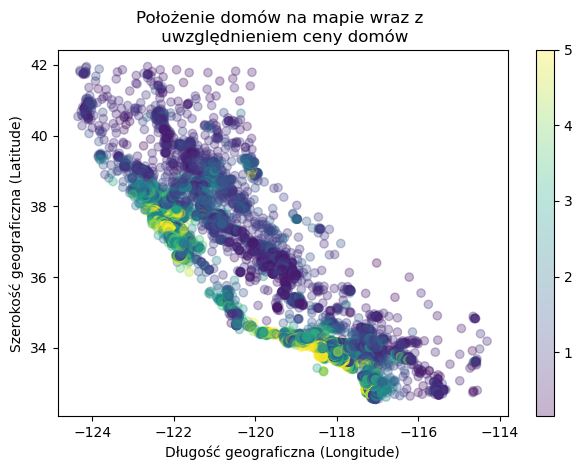

In [12]:
plt.scatter(x=df['Longitude'], y=df['Latitude'], c=df['MedHouseVal'], cmap='viridis', alpha=0.3)
plt.title('Położenie domów na mapie wraz z \n uwzględnieniem ceny domów')
plt.xlabel('Długość geograficzna (Longitude)')
plt.ylabel('Szerokość geograficzna (Latitude)')
plt.colorbar()
plt.tight_layout()
plt.show()

# Wykres korelacji (heatmap) przedstawia korelacje pomiędzy cechami zbioru danych. Oczywistą obserwacją (jak w każdym przypadku bez względu na zbiór danych) każda cecha do siebie nawzajem ma najwyższą wartość korelacji, czyli równą 1. Z interesujących rzeczy można odczytać, że najwyższą korelację mają cechy: AveBedrms - AveRooms (0.85), MedInc - MedHouseVal (0.69), MedInc - AveRooms (0.33), zaś cechy z wręcz ujemną korelacją to: Latitude - Longitude (-0.92). Reszta cech posiada, albo lekko pozytywną lub ujemną korelację, więc reszta cech jest dość słabo ze sobą skorelowana.

In [13]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


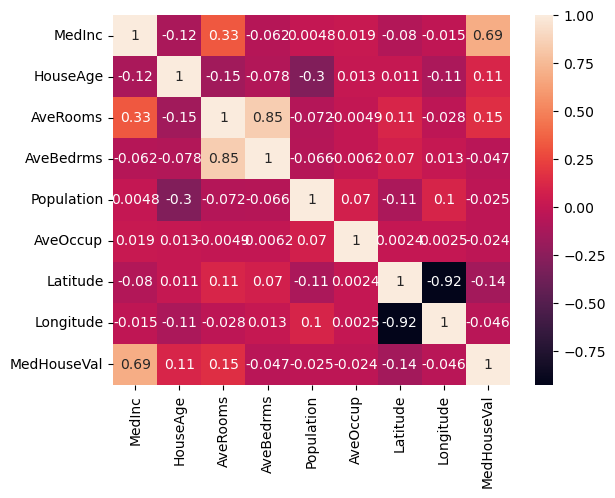

In [14]:
sns.heatmap(df.corr(), annot=True)
plt.show()

# VIF to technika sprawdzania korelacji cech, z tą różnicą, że .corr() sprawdza korelację pomiędzy dwoma cechami, zaś VIF sprawdza korelację jednej cechy ze wszystkimi pozostałymi cechami. Jeśli VIF wynosi około 1 to oznacza, że nie wykazuje korelacji z innymi predykatorami (inne cechy próbują przewidzieć określoną cechę), jeśli VIF wynosi od 1-5 to znaczy, że korelacja jest umiarkowana, zaś jeśli VIF > 10 to świadczy o silnej multikolinearności co może wymagać podjęcia działań korygujących.

In [15]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
X = df.drop('MedHouseVal', axis=1)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

      feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


# Podział danych na treningowe i testowe

In [16]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

columns_to_standardize = X.columns.tolist()
scaler = StandardScaler()
X_train_scaled[columns_to_standardize] = scaler.fit_transform(X_train[columns_to_standardize])
X_test_scaled[columns_to_standardize] = scaler.transform(X_test[columns_to_standardize])

# Regresja Liniowa

In [18]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [19]:
y_pred_lr = model_lr.predict(X_test_scaled)

print('MAE (średni błąd bezwzględny):', mean_absolute_error(y_test, y_pred_lr))
print('RMSE (pierwiastek błędu średniokwadratowego):', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print('R^2 (współczynnik determinacji)', r2_score(y_test, y_pred_lr))

MAE (średni błąd bezwzględny): 0.5332001304956565
RMSE (pierwiastek błędu średniokwadratowego): 0.7455813830127763
R^2 (współczynnik determinacji) 0.575787706032451


# Modele: Lasso, Ridge, ElasticNet

## Wcześniejszy VIF na niektórych cechach wykazywał dość duże wartości świadczące o multilinearności. Jako rozwiązanie tego problemu można zastosować regularyzację, czyli dodaniu kary do funkcji straty za zbyt duże wagi. Modele takie jak: Lasso, Ridge, ElasticNet oprócz samej sumy różnic między wartością przewidzianą, a faktyczną (jak w Regresji Liniowej) to mają dodane do wzoru część, której zadaniem jest zredukowanie zbyt dużych wag.
## 1. Lasso - suma wartości bewzględnych wag.
## 2. Ridge - suma kwadratów wag.
## 3. ElasticNet - suma wartości bewzględnych wag oraz suma kwadratów wag.

In [20]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

lasso_scores = []
ridge_scores = []
elastic_net_scores = []
y_pred_all_models = []

coefficient_estimates = pd.DataFrame()
coefficient_estimates['Columns'] = X_train_scaled.columns

In [21]:
# https://www.geeksforgeeks.org/machine-learning/implementation-of-lasso-ridge-and-elastic-net/
for type_model in range(3):
    for alpha_value in alpha_list:
        if type_model == 0:
            lasso = Lasso(alpha = alpha_value)
            lasso.fit(X_train_scaled, y_train)
            y_pred = lasso.predict(X_test_scaled)

            lasso_scores.append({
                'alpha' : alpha_value,
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R^2': r2_score(y_test, y_pred)
            })

            y_pred_all_models.append({
                f'Lasso, alpha = {alpha_value}': y_pred
            })

            coefficient_estimates[f'Model: Lasso, Alhpa: {alpha_value}'] = pd.Series(lasso.coef_)
        elif type_model == 1:
            ridge = Ridge(alpha = alpha_value)
            ridge.fit(X_train_scaled, y_train)
            y_pred = ridge.predict(X_test_scaled)

            ridge_scores.append({
                'alpha' : alpha_value,
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R^2': r2_score(y_test, y_pred)
            })

            y_pred_all_models.append({
                f'Ridge, alpha = {alpha_value}': y_pred
            })

            coefficient_estimates[f'Model: Ridge, Alhpa: {alpha_value}'] = pd.Series(ridge.coef_)
        elif type_model == 2:
            elastic_net = ElasticNet(alpha = alpha_value)
            elastic_net.fit(X_train_scaled, y_train)
            y_pred = elastic_net.predict(X_test_scaled)

            elastic_net_scores.append({
                'alpha' : alpha_value,
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R^2': r2_score(y_test, y_pred)
            })

            y_pred_all_models.append({
                f'ElasticNet, alpha = {alpha_value}': y_pred
            })

            coefficient_estimates[f'Model: ElasticNet, Alhpa: {alpha_value}'] = pd.Series(elastic_net.coef_)

In [22]:
print('Wyniki dla modeli Lasso:\n', pd.DataFrame(lasso_scores))
print('\nWyniki dla modeli Ridge:\n', pd.DataFrame(ridge_scores))
print('\nWyniki dla modeli ElasticNet:\n', pd.DataFrame(elastic_net_scores))
print('\nWyniki Coef dla wszystkich modeli\n', coefficient_estimates.T)

Wyniki dla modeli Lasso:
      alpha       MAE      RMSE       R^2
0    0.001  0.533145  0.744642  0.576856
1    0.010  0.535326  0.740442  0.581615
2    0.100  0.622201  0.824396  0.481361
3    1.000  0.906069  1.144856 -0.000219
4   10.000  0.906069  1.144856 -0.000219
5  100.000  0.906069  1.144856 -0.000219

Wyniki dla modeli Ridge:
      alpha       MAE      RMSE       R^2
0    0.001  0.533200  0.745581  0.575788
1    0.010  0.533200  0.745581  0.575788
2    0.100  0.533199  0.745579  0.575791
3    1.000  0.533193  0.745557  0.575816
4   10.000  0.533138  0.745342  0.576060
5  100.000  0.533014  0.743819  0.577791

Wyniki dla modeli ElasticNet:
      alpha       MAE      RMSE       R^2
0    0.001  0.533123  0.744917  0.576543
1    0.010  0.534077  0.741588  0.580319
2    0.100  0.597041  0.797406  0.514765
3    1.000  0.805995  1.021876  0.203126
4   10.000  0.906069  1.144856 -0.000219
5  100.000  0.906069  1.144856 -0.000219

Wyniki Coef dla wszystkich modeli
                   

In [23]:
y_pred_all_models

[{'Lasso, alpha = 0.001': array([0.72592298, 1.76090866, 2.69570697, ..., 4.46264973, 1.19821254,
         2.00356126])},
 {'Lasso, alpha = 0.01': array([0.78787312, 1.73253525, 2.5649099 , ..., 4.40562063, 1.2930991 ,
         1.95300562])},
 {'Lasso, alpha = 0.1': array([1.21842882, 1.58283222, 2.10845347, ..., 4.02860631, 1.71943859,
         1.85888548])},
 {'Lasso, alpha = 1': array([2.07194694, 2.07194694, 2.07194694, ..., 2.07194694, 2.07194694,
         2.07194694])},
 {'Lasso, alpha = 10': array([2.07194694, 2.07194694, 2.07194694, ..., 2.07194694, 2.07194694,
         2.07194694])},
 {'Lasso, alpha = 100': array([2.07194694, 2.07194694, 2.07194694, ..., 2.07194694, 2.07194694,
         2.07194694])},
 {'Ridge, alpha = 0.001': array([0.71912319, 1.7640164 , 2.70965848, ..., 4.46876987, 1.18751165,
         2.00940233])},
 {'Ridge, alpha = 0.01': array([0.71912634, 1.76401487, 2.70965533, ..., 4.46876723, 1.18751579,
         2.00940069])},
 {'Ridge, alpha = 0.1': array([0.7191

# Wykres przedstawia zmiany współczynnika determinacji (R^2) ze względu na parametr alpha. Model Ridge przy zmianie tego współczynnika zachowuje swoją skuteczność, w przedziwieństwie do modelów: Lasso oraz ElasticNet, które dla alpha = 0.01 skuteczność zaczyna spadać, a dla alpha > 0.01 skuteczność spada do zera.

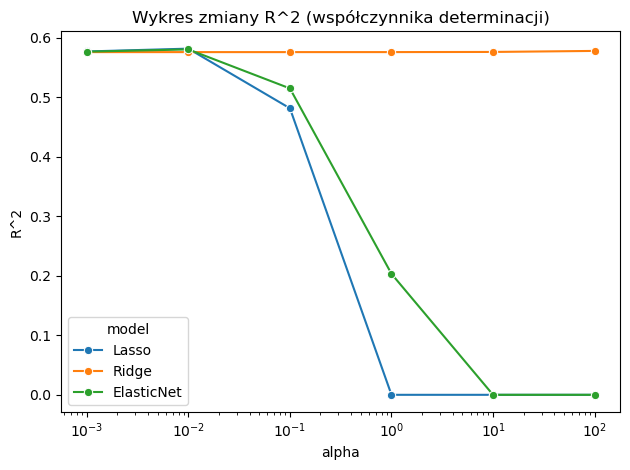

In [24]:
# https://pandas.pydata.org/docs/user_guide/merging.html
df_lasso = pd.DataFrame(lasso_scores)
df_lasso['model'] = 'Lasso'
df_ridge = pd.DataFrame(ridge_scores)
df_ridge['model'] = 'Ridge'
df_elastic_net = pd.DataFrame(elastic_net_scores)
df_elastic_net['model'] = 'ElasticNet'
df_lasso_ridge_elastic_net = pd.concat([df_lasso, df_ridge, df_elastic_net])

sns.lineplot(x='alpha', y='R^2', hue='model', marker='o', data=df_lasso_ridge_elastic_net)
plt.xscale('log')
plt.title('Wykres zmiany R^2 (współczynnika determinacji)')
plt.tight_layout()
plt.show()

# Random Forest

In [25]:
model_random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
model_random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred_random_forest = model_random_forest.predict(X_test)

print('MAE (średni błąd bezwzględny):', mean_absolute_error(y_test, y_pred_random_forest))
print('RMSE (pierwiastek błędu średniokwadratowego):', np.sqrt(mean_squared_error(y_test, y_pred_random_forest)))
print('R^2 (współczynnik determinacji)', r2_score(y_test, y_pred_random_forest))

MAE (średni błąd bezwzględny): 0.32754256845930246
RMSE (pierwiastek błędu średniokwadratowego): 0.5053399773665033
R^2 (współczynnik determinacji) 0.8051230593157366


# Wykres przedstawia ważność poszczególnych cech. Cecha MedInc wykazuje najwyższy wpływ (52%) na trening modelu, zaś pozostałe wykazują znacznie niższy wpływ na trening.

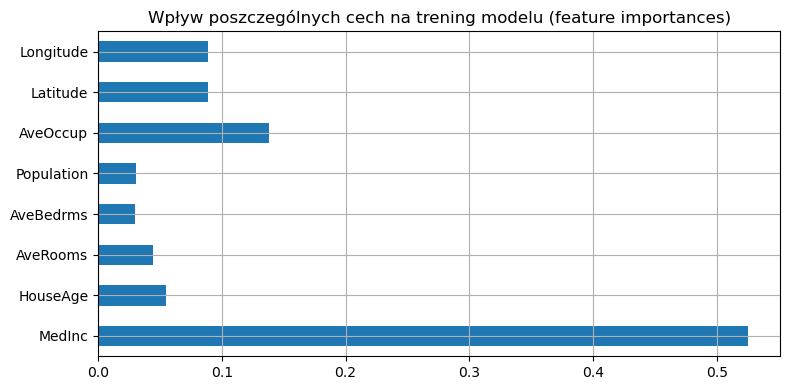

In [27]:
forest_importances = pd.Series(model_random_forest.feature_importances_, index=X.columns)

fig, ax = plt.subplots(figsize=(8, 4))

forest_importances.plot.barh()
ax.set_title('Wpływ poszczególnych cech na trening modelu (feature importances)')
ax.grid()
plt.tight_layout()
plt.show()

In [28]:
feature_importances_values = dict(zip(X.columns, model_random_forest.feature_importances_))
feature_importances_values_sorted_desc = sorted(feature_importances_values.items(), key=operator.itemgetter(1), reverse=True)
feature_importances_values_sorted_desc

[('MedInc', 0.5248714775266793),
 ('AveOccup', 0.1384428140532659),
 ('Latitude', 0.08893574160843591),
 ('Longitude', 0.08862881090121001),
 ('HouseAge', 0.05459321807686177),
 ('AveRooms', 0.04427184750632705),
 ('Population', 0.030649781480378356),
 ('AveBedrms', 0.0296063088468417)]

# Wykres Residuów dla modelów: Random Forest, Regresji Liniowej oraz najlepszych wyników (spośród różnych ustawień parametru alpha) dla modeli: Lasso, Ridge i ElasticNet.

## Model Random Forest wydaje się skupiać wyniki blisko zera, chociaż nie wszystkie są tam tak blisko, ale wyniki modelach liniowych są jeszcze bardziej rozrzucone i słabiej skupione do linii. Tak jak w Random Forest daje mniejsze zakresy, więc posiada wyższą skuteczność, zaś modele liniowe (Lasso, Ridge, ElasticNet) punkty leżą w dalszych zakresach, a sama mniejsza skuteczność o ponad 20% pokazuje znacznie większą różnicę pomiędzy tymi modelami na wykresach.

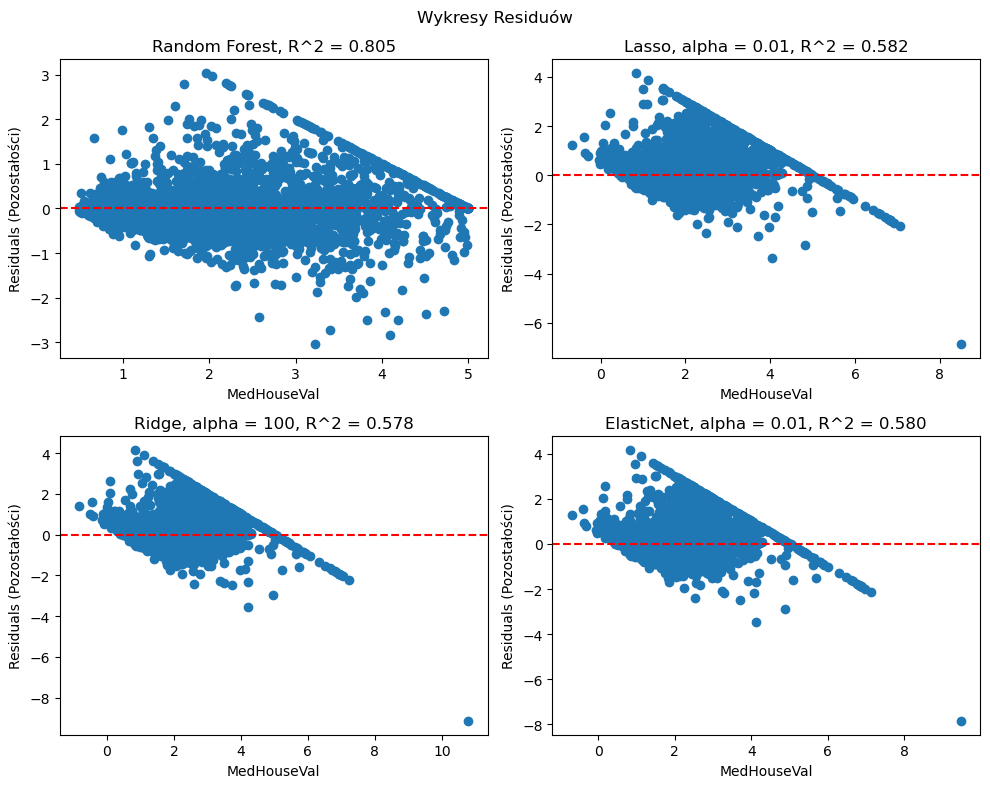

In [29]:
# https://www.geeksforgeeks.org/python/how-to-create-a-residual-plot-in-python/
res1 = y_test - y_pred_random_forest
res2 = y_test - y_pred_all_models[1]['Lasso, alpha = 0.01']
res3 = y_test - y_pred_all_models[11]['Ridge, alpha = 100']
res4 = y_test - y_pred_all_models[13]['ElasticNet, alpha = 0.01']

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Wykresy Residuów')

ax[0, 0].scatter(y_pred_random_forest, res1)
ax[0, 0].axhline(y=0, color='r', linestyle='--')
ax[0, 0].set_title(f'Random Forest, R^2 = {r2_score(y_test, y_pred_random_forest):.3f}')
ax[0, 0].set_xlabel('MedHouseVal')
ax[0, 0].set_ylabel('Residuals (Pozostałości)')

ax[0, 1].scatter(y_pred_all_models[1]['Lasso, alpha = 0.01'], res2)
ax[0, 1].axhline(y=0, color='r', linestyle='--')
ax[0, 1].set_title(f'Lasso, alpha = {lasso_scores[1]['alpha']}, R^2 = {lasso_scores[1]['R^2']:.3f}')
ax[0, 1].set_xlabel('MedHouseVal')
ax[0, 1].set_ylabel('Residuals (Pozostałości)')

ax[1, 0].scatter(y_pred_all_models[11]['Ridge, alpha = 100'], res3)
ax[1, 0].axhline(y=0, color='r', linestyle='--')
ax[1, 0].set_title(f'Ridge, alpha = {ridge_scores[5]['alpha']}, R^2 = {ridge_scores[5]['R^2']:.3f}')
ax[1, 0].set_xlabel('MedHouseVal')
ax[1, 0].set_ylabel('Residuals (Pozostałości)')

ax[1, 1].scatter(y_pred_all_models[13]['ElasticNet, alpha = 0.01'], res4)
ax[1, 1].axhline(y=0, color='r', linestyle='--')
ax[1, 1].set_title(f'ElasticNet, alpha = {elastic_net_scores[1]['alpha']}, R^2 = {elastic_net_scores[1]['R^2']:.3f}')
ax[1, 1].set_xlabel('MedHouseVal')
ax[1, 1].set_ylabel('Residuals (Pozostałości)')

plt.tight_layout()
plt.show()

# Przedstawienie skuteczności modeli na wykresie słupkowym oraz dane o nich takie jak: MAE, RMSE, R^2 w postaci tabeli

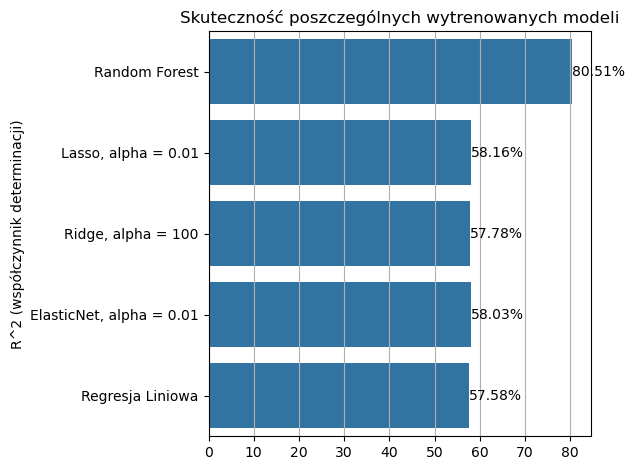

In [30]:
R2_models_scores = {
    'Random Forest': r2_score(y_test, y_pred_random_forest) * 100,
    'Lasso, alpha = 0.01': lasso_scores[1]['R^2'] * 100,
    'Ridge, alpha = 100': ridge_scores[5]['R^2'] * 100,
    'ElasticNet, alpha = 0.01': elastic_net_scores[1]['R^2'] * 100,
    'Regresja Liniowa': r2_score(y_test, y_pred_lr) * 100
}

ax = sns.barplot(R2_models_scores, orient='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('Skuteczność poszczególnych wytrenowanych modeli')
plt.ylabel('R^2 (współczynnik determinacji)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [31]:
models_scores = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'MAE': mean_absolute_error(y_test, y_pred_random_forest),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_random_forest)),
        'R^2': r2_score(y_test, y_pred_random_forest)
    },
    {
        'Model': 'Lasso, alpha = 0.01',
        'MAE': lasso_scores[1]['MAE'],
        'RMSE': lasso_scores[1]['RMSE'],
        'R^2': lasso_scores[1]['R^2']
    },
    {
        'Model': 'Ridge, alpha = 100',
        'MAE': ridge_scores[5]['MAE'],
        'RMSE': ridge_scores[5]['RMSE'],
        'R^2': ridge_scores[5]['R^2']
    },
    {
        'Model': 'ElasticNet, alpha = 0.01',
        'MAE': elastic_net_scores[1]['MAE'],
        'RMSE': elastic_net_scores[1]['RMSE'],
        'R^2': elastic_net_scores[1]['R^2']
    },
    {
        'Model': 'Regresja Liniowa',
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        'R^2': r2_score(y_test, y_pred_lr)
    }
])

print('Wyniki poszczególnych modeli w postaci tabeli:\n', models_scores)

Wyniki poszczególnych modeli w postaci tabeli:
                       Model       MAE      RMSE       R^2
0             Random Forest  0.327543  0.505340  0.805123
1       Lasso, alpha = 0.01  0.535326  0.740442  0.581615
2        Ridge, alpha = 100  0.533014  0.743819  0.577791
3  ElasticNet, alpha = 0.01  0.534077  0.741588  0.580319
4          Regresja Liniowa  0.533200  0.745581  0.575788
